# Review Rating Prediction
### Amazon Product Reviews | Multi-class Text Classification

Predict the star rating a customer would give from the text of their
review alone, so that sentiment can be quantified across channels where
no rating exists.

**Dataset:** Amazon Cell Phones & Accessories — 194,439 reviews, 2007–2013 | 9 columns
**Target:** overall rating, 1–5 stars | **Approach:** CRISP-DM

## 0. Business Understanding

### Background
A star rating is a compact summary of a customer's experience, but it only
exists where a platform collects one. The same customers describe the same
products in support emails, live chat, social posts and returns forms —
all unrated. A seller with 200,000 rated reviews may have far more
unrated text saying the same things, and no way to measure it.

### Business Problem
Quantify customer sentiment across channels where no rating is captured.
This supports:

- Measuring product satisfaction from support and social text
- Flagging likely 1-star experiences for intervention before they are
  posted publicly
- Detecting quality problems in a product line earlier than review volume
  alone would reveal

### ML Objective
Build a **multi-class text classifier** that predicts the 1–5 star rating
from review text alone, using no product, price or reviewer metadata.

### Success Criteria
- **Baseline to beat:** majority class. Predicting 5 stars for every
  review achieves 55.9% accuracy, so accuracy below that is worthless.
- **Primary metric:** macro F1. The classes are imbalanced 10:1 between
  5-star (55.9%) and 2-star (5.7%), and macro F1 weights every class
  equally rather than letting the majority dominate.
- **Secondary metric:** mean absolute error in stars. The target is
  **ordinal** — predicting 4 when the truth is 5 is a smaller mistake than
  predicting 1. Accuracy treats both as equally wrong; MAE does not.
- **Complexity check:** a fine-tuned transformer must beat TF-IDF by
  enough to justify a model roughly 400× larger requiring GPU training.

### Model Validation Checks
- Train and CV scores within one standard deviation
- Test set evaluated once, after model selection
- No leakage: text vectorisers fitted inside a pipeline, on training data only

# Data Loading

In [1]:
import json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

rows = [json.loads(line) for line in open("Cell_Phones_and_Accessories_5.json")]
df = pd.DataFrame(rows)

print(df.shape)
df.head()

(194439, 9)


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A30TL5EWN6DFXT,120401325X,christina,"[0, 0]",They look good and stick good! I just don't li...,4.0,Looks Good,1400630400,"05 21, 2014"
1,ASY55RVNIL0UD,120401325X,emily l.,"[0, 0]",These stickers work like the review says they ...,5.0,Really great product.,1389657600,"01 14, 2014"
2,A2TMXE2AFO7ONB,120401325X,Erica,"[0, 0]",These are awesome and make my phone look so st...,5.0,LOVE LOVE LOVE,1403740800,"06 26, 2014"
3,AWJ0WZQYMYFQ4,120401325X,JM,"[4, 4]",Item arrived in great time and was in perfect ...,4.0,Cute!,1382313600,"10 21, 2013"
4,ATX7CZYFXI1KW,120401325X,patrice m rogoza,"[2, 3]","awesome! stays on, and looks great. can be use...",5.0,leopard home button sticker for iphone 4s,1359849600,"02 3, 2013"


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194439 entries, 0 to 194438
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   reviewerID      194439 non-null  object 
 1   asin            194439 non-null  object 
 2   reviewerName    190920 non-null  object 
 3   helpful         194439 non-null  object 
 4   reviewText      194439 non-null  object 
 5   overall         194439 non-null  float64
 6   summary         194439 non-null  object 
 7   unixReviewTime  194439 non-null  int64  
 8   reviewTime      194439 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 13.4+ MB


In [3]:
df.isnull().sum()

reviewerID           0
asin                 0
reviewerName      3519
helpful              0
reviewText           0
overall              0
summary              0
unixReviewTime       0
reviewTime           0
dtype: int64

# 1. Data Understanding

In [4]:
print("reviews:", len(df))
print("products:", df["asin"].nunique())
print("reviewers:", df["reviewerID"].nunique())
print("date range:", df["reviewTime"].min(), "to", df["reviewTime"].max())

reviews: 194439
products: 10429
reviewers: 27879
date range: 01 1, 2007 to 12 9, 2013


In [5]:
df["overall"].value_counts().sort_index()

overall
1.0     13279
2.0     11064
3.0     21439
4.0     39993
5.0    108664
Name: count, dtype: int64

In [6]:
(df["overall"].value_counts(normalize=True).sort_index() * 100).round(1)

overall
1.0     6.8
2.0     5.7
3.0    11.0
4.0    20.6
5.0    55.9
Name: proportion, dtype: float64

In [7]:
# Text length — determines the max token length for the transformer later
df["word_count"] = df["reviewText"].astype(str).str.split().str.len()
df["char_count"] = df["reviewText"].astype(str).str.len()
df[["word_count", "char_count"]].describe().round(0)

,word_count,char_count
count,194439.0,194439.0
mean,92.0,492.0
std,135.0,749.0
min,0.0,0.0
25%,28.0,143.0
50%,48.0,248.0
75%,100.0,532.0
max,5263.0,32110.0


In [8]:
# Empty reviews
print("empty reviewText:", (df["reviewText"].astype(str).str.strip() == "").sum())
print("under 3 words:", (df["word_count"] < 3).sum())

empty reviewText: 99
under 3 words: 531


### Columns

- **reviewerID** — reviewer identifier. Not used: a model keyed on
  reviewer would not generalise to new customers.
- **asin** — Amazon product identifier. Not used: the objective is to
  predict from text alone, and product identity would leak information
  about typical ratings for that item.
- **reviewerName** — display name. 3,519 nulls. Not used.
- **helpful** — `[helpful_votes, total_votes]`. **Not usable as a feature**
  — votes accrue *after* the review is posted, so they would not be
  available at prediction time. Target leakage.
- **reviewText** — the review body. **The only predictor used.**
- **overall** — star rating 1–5. **The target.**
- **summary** — the review headline. A candidate second text field,
  tested separately in feature engineering.
- **unixReviewTime / reviewTime** — timestamp, same value in two formats.
  Not used as a feature; retained for the temporal split check.

### Structure
One row per review. Reviews are nested within products (10,429) and
reviewers (27,879), so the same reviewer appears multiple times — relevant
to the split strategy discussed in section 4.

In [9]:
# Rough token estimate: ~1.3 tokens per word
print("over 200 words:", (df["word_count"] > 200).mean().round(4))
print("over 400 words:", (df["word_count"] > 400).mean().round(4))
print("95th percentile:", df["word_count"].quantile(0.95))
print("99th percentile:", df["word_count"].quantile(0.99))

over 200 words: 0.1039
over 400 words: 0.028
95th percentile: 307.0
99th percentile: 614.0


In [10]:
# Does review length relate to rating?
df.groupby("overall")["word_count"].agg(["mean", "median", "count"]).round(1)

,mean,median,count
overall,,,
1.0,77.3,46.0,13279
2.0,96.7,55.0,11064
3.0,96.2,52.0,21439
4.0,110.3,59.0,39993
5.0,85.0,43.0,108664


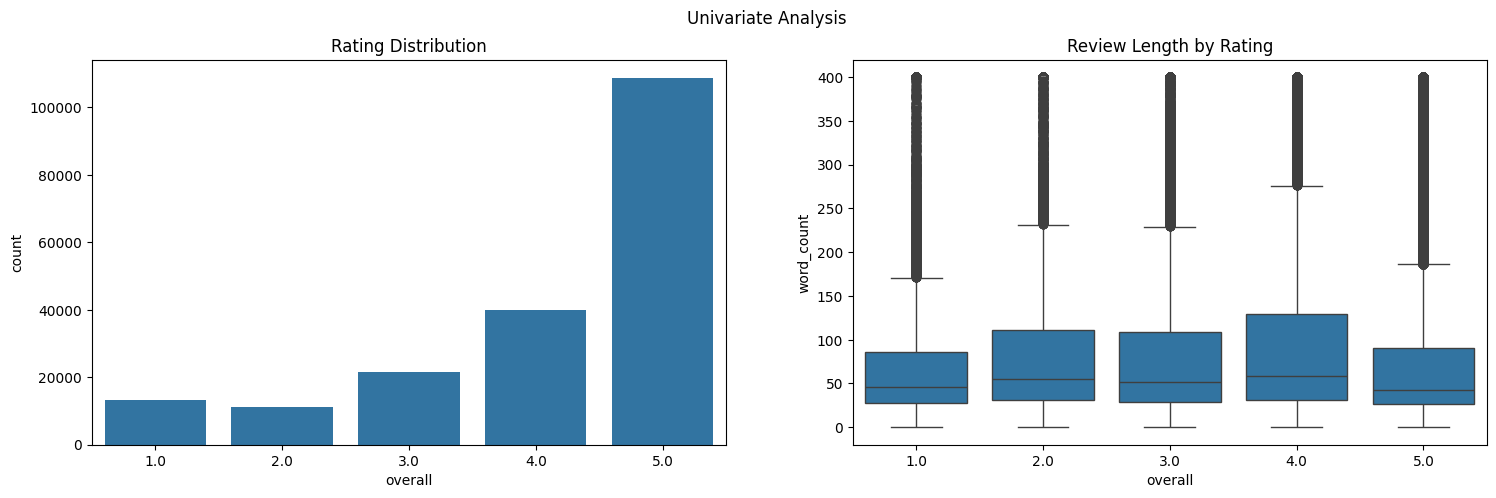

In [11]:
plt.rcParams["figure.figsize"] = (18, 5)
plt.subplot(1, 2, 1)
sns.countplot(x=df["overall"])
plt.title("Rating Distribution")
plt.subplot(1, 2, 2)
sns.boxplot(x=df["overall"], y=df["word_count"].clip(upper=400))
plt.title("Review Length by Rating")
plt.suptitle("Univariate Analysis")
plt.show()

Review length relates to rating **non-monotonically**: 4-star reviews are
longest (mean 110 words), while 5-star (85) and 1-star (77) are shortest.
Extreme opinions are stated briefly; qualified ones require explanation.
Length is therefore a weak feature that linear models cannot exploit
directly.

In [12]:
for rating in [1, 3, 5]:
    print(f"\n{'='*60}\n{rating} STAR\n{'='*60}")
    for txt in df[df["overall"] == rating]["reviewText"].sample(3, random_state=42):
        print("-", txt[:300], "\n")


1 STAR
- I see many glowing reviews on this case and I am mystified.  Do you want a case that fits very loosely on your phone that is likely to start coming off in your pocket?  Do you like it when you try to push the power button or volume but instead push the case right off the side of the phone?  If you d 

- I also bought the Hyperion 7000mAh, plan on taking a dremel to an Otterbox case. You can not really use the 4200mAh if you carve out the Otterbox for the 7000mAh.==============================================================================================THE OEM BATTER GIVES YOU AT BEST 6 HOURS.  W 

- One... If u get the case wet at ALL the color comes off!!!!Two... It messes up with Reception and your Wi-Fi connection.. In other words you'll drops calls ALOT!!!Three.. Breaks so easy.... So what it comes down to is that u get what u paid for... 


3 STAR
- Not sure if it is the Nexus app or the device, but this cable doesn't always work. Sometimes it reads my flash drive and

In [13]:
# Most common words per rating — after removing stopwords
from sklearn.feature_extraction.text import CountVectorizer

for rating in [1, 5]:
    cv = CountVectorizer(stop_words="english", max_features=15)
    cv.fit(df[df["overall"] == rating]["reviewText"].astype(str))
    print(f"{rating} star:", list(cv.vocabulary_.keys()))

1 star: ['charge', 'phone', 'just', 'time', 'product', 'case', 'did', 'buy', 'don', 'work', 'battery', 'screen', 'like', 'iphone', 'use']
5 star: ['like', 'great', 'phone', 'just', 'good', 'case', 'battery', 'charge', 'love', 'charger', 'product', 'use', 'iphone', 'really', 'screen']


### Text observations

- Vocabulary overlaps substantially between rating classes: `phone`,
  `case`, `battery`, `charge`, `screen` appear in both 1-star and 5-star
  top terms. These are product nouns, not sentiment. Discriminating terms
  are sparse — `great`, `good`, `love` versus `did`, `don`, `work`. This
  motivates TF-IDF, which downweights terms common across the corpus.
- Some 5-star reviews are extremely short ("Worth the wait.") and carry
  almost no signal.
- Mixed sentiment is common: one sampled 5-star review contains "It took
  forever for it to ship tho". The rating reflects the product; the text
  contains a complaint about delivery.
- 3-star reviews are genuinely ambivalent and contain both positive and
  negative statements, which makes them the hardest class and the one
  most exposed to confusion in both directions.
- Formatting is inconsistent: runs of punctuation, missing spaces after
  full stops, all-caps emphasis.

# Data Cleaning

In [14]:
# Drop empty and near-empty reviews — no signal to learn from
before = len(df)
df = df[df["reviewText"].astype(str).str.strip() != ""]
df = df[df["word_count"] >= 3]
print(f"{before:,} -> {len(df):,} ({before - len(df)} removed)")

194,439 -> 193,908 (531 removed)


In [15]:
# Duplicate review text — copy-paste or bot reviews
print("duplicate reviewText:", df["reviewText"].duplicated().sum())

duplicate reviewText: 32


In [16]:
print("over 200 words:", round((df["word_count"] > 200).mean() * 100, 2), "%")
print("95th pct:", df["word_count"].quantile(0.95))
print("99th pct:", df["word_count"].quantile(0.99))

over 200 words: 10.42 %
95th pct: 307.0
99th pct: 614.929999999993


In [17]:
df = df.drop_duplicates(subset=["reviewText"])
print(len(df))

193876


`max_length=256` tokens was chosen for the transformer. 89.6% of reviews
are under 200 words and the 95th percentile is 307, so this covers the
substantial majority in full while training roughly twice as fast as the
512-token maximum. Truncated reviews lose their tail; the opening
typically carries the verdict.

# Train/Test Split

In [19]:
print("reviews per reviewer:", round(len(df) / df["reviewerID"].nunique(), 1))
print("reviewers with >1 review:", (df["reviewerID"].value_counts() > 1).sum())
print("total reviewers:", df["reviewerID"].nunique())

reviews per reviewer: 7.0
reviewers with >1 review: 27871
total reviewers: 27878


In [20]:
from sklearn.model_selection import GroupShuffleSplit

X = df["reviewText"]
y = df["overall"].astype(int)
groups = df["reviewerID"]

splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train = groups.iloc[train_idx]

print(f"train: {len(X_train):,}  test: {len(X_test):,}")
print("reviewer overlap:", len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))

train: 155,430  test: 38,446
reviewer overlap: 0


In [21]:
# Class balance is preserved approximately, though GroupShuffleSplit
# cannot stratify — check it didn't drift
pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
}).round(4)

,train,test
overall,,
1,0.0674,0.0721
2,0.0568,0.0577
3,0.1105,0.1099
4,0.2071,0.2003
5,0.5581,0.5601


### Split strategy

99.97% of reviewers (27,871 of 27,878) appear more than once, averaging 7
reviews each. A random split would place the same person's reviews on both
sides, allowing the model to learn individual writing style and rating
habits rather than sentiment — **group leakage**.

`GroupShuffleSplit` on `reviewerID` ensures every reviewer falls entirely
within either train or test. Reviewer overlap between the two sets is zero.

This cannot stratify by rating simultaneously, so class proportions are
checked rather than enforced.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, mean_absolute_error,
                             classification_report, confusion_matrix)

In [23]:
results = []

def evaluate(pred, name):
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    mae = mean_absolute_error(y_test, pred)
    results.append({"model": name, "accuracy": round(acc, 4),
                    "macro_f1": round(f1, 4), "MAE": round(mae, 4)})
    print(f"{name:32s} acc {acc:.4f}  macro-F1 {f1:.4f}  MAE {mae:.4f}")

### 6.1 Majority Class Baseline
Predicts 5 stars for every review. No model. Any classifier scoring below
55.8% accuracy is worse than this.

In [24]:
majority_pred = np.full(len(y_test), 5)
evaluate(majority_pred, "Majority class (always 5)")

Majority class (always 5)        acc 0.5601  macro-F1 0.1436  MAE 0.8813


### 6.2 TF-IDF + Logistic Regression
Term frequency–inverse document frequency downweights terms common across
the corpus — the shared product nouns (`phone`, `case`, `battery`)
identified in exploration — leaving the discriminating sentiment words.

In [25]:
from sklearn.linear_model import LogisticRegression

lr = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                              min_df=3, stop_words="english")),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])
lr.fit(X_train, y_train)
evaluate(lr.predict(X_test), "TF-IDF + Logistic Regression")

TF-IDF + Logistic Regression     acc 0.6460  macro-F1 0.4418  MAE 0.5296


### 6.3 TF-IDF + Linear SVM
Linear SVMs are a strong default for high-dimensional sparse text features
and often outperform logistic regression on this class of problem.

In [26]:
from sklearn.svm import LinearSVC

svm = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                              min_df=3, stop_words="english")),
    ("model", LinearSVC(random_state=42)),
])
svm.fit(X_train, y_train)
evaluate(svm.predict(X_test), "TF-IDF + Linear SVM")

TF-IDF + Linear SVM              acc 0.6241  macro-F1 0.4295  MAE 0.5532


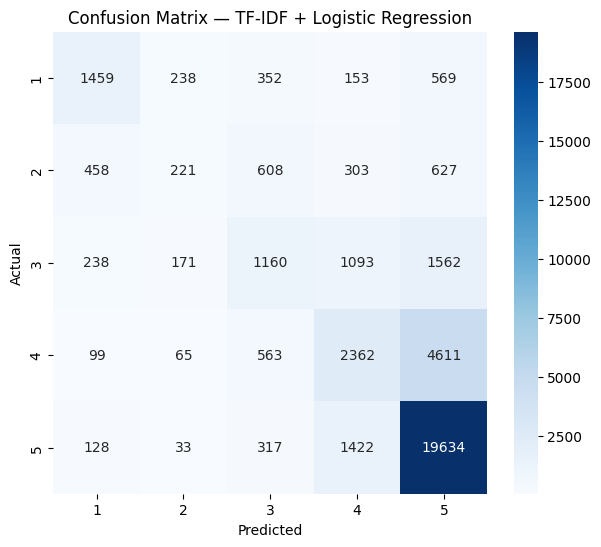

In [27]:
cm = confusion_matrix(y_test, lr.predict(X_test))
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — TF-IDF + Logistic Regression")
plt.show()

In [28]:
print(classification_report(y_test, lr.predict(X_test), digits=3))

              precision    recall  f1-score   support

           1      0.613     0.527     0.566      2771
           2      0.304     0.100     0.150      2217
           3      0.387     0.275     0.321      4224
           4      0.443     0.307     0.362      7700
           5      0.727     0.912     0.809     21534

    accuracy                          0.646     38446
   macro avg      0.495     0.424     0.442     38446
weighted avg      0.600     0.646     0.610     38446



In [29]:
lr_bal = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                              min_df=3, stop_words="english")),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                 random_state=42)),
])
lr_bal.fit(X_train, y_train)
evaluate(lr_bal.predict(X_test), "TF-IDF + LogReg (balanced)")

TF-IDF + LogReg (balanced)       acc 0.5786  macro-F1 0.4536  MAE 0.6096


In [30]:
train_df = pd.DataFrame({"text": X_train.values, "label": y_train.values})
test_df = pd.DataFrame({"text": X_test.values, "label": y_test.values})

train_df.to_csv("train_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

print(train_df.shape, test_df.shape)

(155430, 2) (38446, 2)
